<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_modeling_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [2]:
# Modeling
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding = 'same', input_shape=(256, 256, 3)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding = 'same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1000, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [3]:
def fit_and_del(set_path, target_path):
    # Load data
    train_set_pt = np.load(set_path, allow_pickle=True)
    train_target_pt = np.load(target_path, allow_pickle=True)

    # Normalization
    train_set_pt_scaled = train_set_pt / 255.0
    
    del train_set_pt
    
    # train_set, validation_set 분리
    x_train, x_val, y_train, y_val = train_test_split(
        train_set_pt_scaled, train_target_pt, test_size=0.2, random_state=42
    )

    del train_set_pt_scaled
    del train_target_pt

    # Training
    model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
               batch_size = 64, callbacks=[early_stopping_cb])

    del x_train
    del x_val
    del y_train
    del y_val

In [4]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [5]:
train_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled'
train_path_list = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_set_part_path = os.path.join(dirname, filename)
            train_path_list.append(train_set_part_path)

train_path_list.sort()

In [6]:
train_target_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part'
train_target_path_list = []

for dirname, _, filenames in os.walk(train_target_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_target_part_path = os.path.join(dirname, filename)
            train_target_path_list.append(train_target_part_path)
        
train_target_path_list.sort()

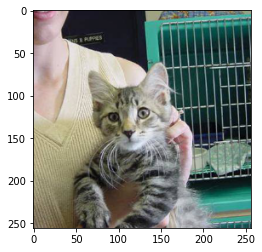

0


In [7]:
a = np.load(train_path_list[0], allow_pickle=True)
b = np.load(train_target_path_list[0], allow_pickle=True)

plt.imshow(a[6])
plt.show()
print(b[6])

In [8]:
for i in range(0, 4):
    a = np.load(train_path_list[i], allow_pickle=True)
    b = np.load(train_target_path_list[i], allow_pickle=True)

    print(len(a), len(b), sep=' ', end='\n')
    print(train_path_list[i], train_target_path_list[i])

    del a
    del b

2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_1.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_1.npy
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_2.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_2.npy
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_3.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_3.npy
2005 2005
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_4.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_4.npy


In [9]:
for i in range(0, 4):
    print('Part {} Training...'.format(i + 1))
    fit_and_del(train_path_list[i], train_target_path_list[i])

Part 1 Training...
Epoch 1/20
25/25 [==============================] - 15s 134ms/step - loss: 2.6216 - accuracy: 0.4919 - val_loss: 0.6928 - val_accuracy: 0.5375
Epoch 2/20
25/25 [==============================] - 1s 46ms/step - loss: 0.6932 - accuracy: 0.4944 - val_loss: 0.6931 - val_accuracy: 0.5375
Epoch 3/20
25/25 [==============================] - 1s 48ms/step - loss: 0.6932 - accuracy: 0.4981 - val_loss: 0.6931 - val_accuracy: 0.4950
Epoch 4/20
25/25 [==============================] - 1s 56ms/step - loss: 0.6929 - accuracy: 0.5294 - val_loss: 0.6932 - val_accuracy: 0.5150
Part 2 Training...
Epoch 1/20
25/25 [==============================] - 3s 111ms/step - loss: 0.6933 - accuracy: 0.4844 - val_loss: 0.6932 - val_accuracy: 0.5050
Epoch 2/20
25/25 [==============================] - 1s 46ms/step - loss: 0.6927 - accuracy: 0.5219 - val_loss: 0.6932 - val_accuracy: 0.4925
Epoch 3/20
25/25 [==============================] - 1s 46ms/step - loss: 0.6923 - accuracy: 0.5256 - val_loss: 0.

In [10]:
# Load Test Set

test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/test_set_scaled/test_scaled.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

In [11]:
test_set_scaled = test_set / 255.0

model.evaluate(test_set_scaled, test_target)

64/64 [==============================] - 1s 12ms/step - loss: 0.7005 - accuracy: 0.4963


[0.7005264759063721, 0.4962926208972931]

In [12]:
from keras.applications import ResNet50

resnet50 = ResNet50(weights=None, include_top=False, input_shape=(256, 256, 3))

model2 = keras.Sequential()
model2.add(resnet50)
model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(1000, activation='relu'))
model2.add(keras.layers.Dropout(0.3))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

In [13]:
def fit_and_del2(set_path, target_path):
    # Load data
    train_set_pt = np.load(set_path, allow_pickle=True)
    train_target_pt = np.load(target_path, allow_pickle=True)

    # Normalization
    train_set_pt_scaled = train_set_pt / 255.0
    
    del train_set_pt
    
    # train_set, validation_set 분리
    x_train, x_val, y_train, y_val = train_test_split(
        train_set_pt_scaled, train_target_pt, test_size=0.2, random_state=42
    )

    del train_set_pt_scaled
    del train_target_pt

    # Training
    model2.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
               batch_size = 64, callbacks=[early_stopping_cb])

    del x_train
    del x_val
    del y_train
    del y_val

In [14]:
for i in range(0, 4):
    print('Part {} Training...'.format(i + 1))
    fit_and_del2(train_path_list[i], train_target_path_list[i])

Part 1 Training...
Epoch 1/20
25/25 [==============================] - 12s 237ms/step - loss: 59.3695 - accuracy: 0.5006 - val_loss: 0.7098 - val_accuracy: 0.5375
Epoch 2/20
25/25 [==============================] - 4s 170ms/step - loss: 2.0888 - accuracy: 0.4806 - val_loss: 0.7025 - val_accuracy: 0.5375
Epoch 3/20
25/25 [==============================] - 4s 172ms/step - loss: 1.2286 - accuracy: 0.4931 - val_loss: 0.6907 - val_accuracy: 0.5375
Epoch 4/20
25/25 [==============================] - 4s 156ms/step - loss: 1.1210 - accuracy: 0.4913 - val_loss: 0.7047 - val_accuracy: 0.4625
Epoch 5/20
25/25 [==============================] - 4s 156ms/step - loss: 0.7966 - accuracy: 0.5250 - val_loss: 0.6950 - val_accuracy: 0.4625
Epoch 6/20
25/25 [==============================] - 4s 166ms/step - loss: 0.7399 - accuracy: 0.5006 - val_loss: 0.6927 - val_accuracy: 0.5375
Part 2 Training...
Epoch 1/20
25/25 [==============================] - 5s 193ms/step - loss: 1.1025 - accuracy: 0.4819 - val_lo

In [15]:
model2.evaluate(test_set_scaled, test_target)

64/64 [==============================] - 2s 31ms/step - loss: 0.6936 - accuracy: 0.4998


[0.6935747861862183, 0.49975284934043884]